In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


def segmentation_weight_sensitivity(
    input_file,
    output_dir=None,
    n_simulations=100000,
    random_seed=42,
    max_rank_heatmap=20
):
    """
    Monte-Carlo sensitivity analysis of segmentation metric weights.

    Generates:

        1. Rank probability heatmap
        2. 1st-place probability plot
        3. Vertical stacked 1st/2nd/3rd probability plot
        4. Ranking statistics CSV
        5. Rank probability CSV
        6. Random weights CSV

    Parameters
    ----------
    input_file : str or Path
        CSV or Excel file containing segmentation results.

    output_dir : str or Path, optional
        Directory where results are saved.
        If None, results are saved beside the input file.

    n_simulations : int
        Number of random weight combinations.
        Default = 100,000.

    random_seed : int
        Random seed for reproducibility.
        Default = 42.

    max_rank_heatmap : int, optional
        Maximum ranking position displayed in the heatmap.
        The CSV still contains all ranking positions.
        Default = 20.

    Returns
    -------
    sensitivity_results : pandas.DataFrame
        Ranking statistics for every image.

    weight_results : pandas.DataFrame
        Randomly generated metric weights.
    """

    # ============================================================
    # 1. LOAD DATA
    # ============================================================

    input_file = Path(input_file)

    if input_file.suffix.lower() == ".csv":

        seg_results = pd.read_csv(input_file)

    elif input_file.suffix.lower() in [".xlsx", ".xls"]:

        seg_results = pd.read_excel(input_file)

    else:

        raise ValueError(
            "Input file must be CSV or Excel "
            "(.csv, .xlsx, .xls)"
        )

    # ============================================================
    # 2. DEFINE SEGMENTATION QUALITY METRICS
    # ============================================================

    score_metrics = [
        "segmented_fraction",
        "mean_region_area",
        "median_region_area",
        "separability",
        "connected_components",
        "threshold_instability"
    ]

    # Check required columns

    missing_columns = [
        column
        for column in score_metrics
        if column not in seg_results.columns
    ]

    if missing_columns:

        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    # Check image ID

    if "image_id" not in seg_results.columns:

        raise ValueError(
            "The input file must contain an 'image_id' column."
        )

    # ============================================================
    # 3. CHECK MISSING VALUES
    # ============================================================

    if seg_results[score_metrics].isnull().any().any():

        missing_metrics = (
            seg_results[score_metrics]
            .isnull()
            .sum()
        )

        missing_metrics = (
            missing_metrics[
                missing_metrics > 0
            ]
        )

        raise ValueError(
            "Missing values found in segmentation metrics:\n"
            f"{missing_metrics}"
        )

    # ============================================================
    # 4. NORMALISE METRICS
    # ============================================================

    scaler = MinMaxScaler()

    normalized = scaler.fit_transform(
        seg_results[score_metrics]
    )

    normalized_results = pd.DataFrame(
        normalized,
        columns=score_metrics,
        index=seg_results.index
    )

    # ------------------------------------------------------------
    # Metrics where LOWER is better
    # ------------------------------------------------------------

    normalized_results[
        "connected_components"
    ] = (
        1
        - normalized_results[
            "connected_components"
        ]
    )

    normalized_results[
        "threshold_instability"
    ] = (
        1
        - normalized_results[
            "threshold_instability"
        ]
    )

    # Convert to NumPy array

    normalized_array = (
        normalized_results[
            score_metrics
        ].to_numpy()
    )

    # ============================================================
    # 5. GENERATE RANDOM WEIGHTS
    # ============================================================

    rng = np.random.default_rng(
        random_seed
    )

    random_weights = rng.dirichlet(
        alpha=np.ones(
            len(score_metrics)
        ),
        size=n_simulations
    )

    weight_results = pd.DataFrame(
        random_weights,
        columns=score_metrics
    )

    weight_results.insert(
        0,
        "simulation",
        np.arange(
            1,
            n_simulations + 1
        )
    )

    # ============================================================
    # 6. CALCULATE SCORES AND RANKS
    # ============================================================

    n_images = len(
        seg_results
    )

    all_ranks = np.zeros(
        (
            n_simulations,
            n_images
        ),
        dtype=np.int16
    )

    for i in range(
        n_simulations
    ):

        # Random metric weights

        weights_i = random_weights[i]

        # Calculate weighted score

        scores = (
            normalized_array
            @ weights_i
        )

        # Rank images

        ranks = (
            pd.Series(scores)
            .rank(
                ascending=False,
                method="min"
            )
            .to_numpy()
        )

        all_ranks[i] = ranks

    image_ids = (
        seg_results[
            "image_id"
        ].to_numpy()
    )

    # ============================================================
    # 7. CALCULATE RANKING STATISTICS
    # ============================================================

    sensitivity_results = pd.DataFrame({

        "image_id": image_ids,

        "first_place_percent":
            np.mean(
                all_ranks == 1,
                axis=0
            ) * 100,

        "second_place_percent":
            np.mean(
                all_ranks == 2,
                axis=0
            ) * 100,

        "third_place_percent":
            np.mean(
                all_ranks == 3,
                axis=0
            ) * 100,

        "top_3_percent":
            np.mean(
                all_ranks <= 3,
                axis=0
            ) * 100,

        "mean_rank":
            np.mean(
                all_ranks,
                axis=0
            ),

        "median_rank":
            np.median(
                all_ranks,
                axis=0
            ),

        "rank_std":
            np.std(
                all_ranks,
                axis=0
            )
    })

    # ------------------------------------------------------------
    # Sort by first-place probability
    # ------------------------------------------------------------

    sensitivity_results = (
        sensitivity_results
        .sort_values(
            [
                "first_place_percent",
                "top_3_percent",
                "mean_rank"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # ============================================================
    # 8. FULL RANK PROBABILITY DISTRIBUTION
    # ============================================================

    rank_probability_matrix = np.zeros(
        (
            n_images,
            n_images
        )
    )

    for rank in range(
        1,
        n_images + 1
    ):

        rank_probability_matrix[
            :,
            rank - 1
        ] = (
            np.mean(
                all_ranks == rank,
                axis=0
            ) * 100
        )

    rank_probability_results = pd.DataFrame(
        rank_probability_matrix,
        columns=[
            f"rank_{rank}_percent"
            for rank in range(
                1,
                n_images + 1
            )
        ]
    )

    rank_probability_results.insert(
        0,
        "image_id",
        image_ids
    )

    # ------------------------------------------------------------
    # Sort rank probabilities using the same image order
    # as sensitivity_results
    # ------------------------------------------------------------

    rank_order = (
        sensitivity_results[
            "image_id"
        ].tolist()
    )

    rank_probability_results = (
        rank_probability_results
        .set_index(
            "image_id"
        )
        .loc[
            rank_order
        ]
        .reset_index()
    )

    # ============================================================
    # 9. OUTPUT DIRECTORY
    # ============================================================

    if output_dir is None:

        output_dir = input_file.parent

    output_dir = Path(
        output_dir
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    parameter_name = (
        input_file.stem
    )

    # ============================================================
    # 10. ROUND TO 6 SIGNIFICANT FIGURES
    # ============================================================

    def round_to_sig_figs(
        dataframe,
        sig_figs=6
    ):

        dataframe = dataframe.copy()

        numeric_columns = (
            dataframe
            .select_dtypes(
                include=[np.number]
            )
            .columns
        )

        for column in numeric_columns:

            dataframe[column] = (
                dataframe[column]
                .map(
                    lambda value:
                    (
                        0
                        if value == 0
                        else float(
                            f"{value:.{sig_figs}g}"
                        )
                    )
                )
            )

        return dataframe

    # Apply rounding only after calculations

    sensitivity_results = (
        round_to_sig_figs(
            sensitivity_results
        )
    )

    rank_probability_results = (
        round_to_sig_figs(
            rank_probability_results
        )
    )

    weight_results = (
        round_to_sig_figs(
            weight_results
        )
    )

    # ============================================================
    # 11. SAVE CSV FILES
    # ============================================================

    # ------------------------------------------------------------
    # Ranking statistics
    # ------------------------------------------------------------

    statistics_file = (
        output_dir
        / f"{parameter_name}_ranking_statistics.csv"
    )

    sensitivity_results.to_csv(
        statistics_file,
        index=False
    )

    # ------------------------------------------------------------
    # Full rank probability distribution
    # ------------------------------------------------------------

    rank_probability_file = (
        output_dir
        / f"{parameter_name}_rank_probability.csv"
    )

    rank_probability_results.to_csv(
        rank_probability_file,
        index=False
    )

    # ------------------------------------------------------------
    # Random weights
    # ------------------------------------------------------------

    weights_file = (
        output_dir
        / f"{parameter_name}_random_weights.csv"
    )

    weight_results.to_csv(
        weights_file,
        index=False
    )

    # ============================================================
    # 12. RANK PROBABILITY HEATMAP
    # ============================================================

    heatmap_data = (
        rank_probability_results
        .set_index(
            "image_id"
        )
    )

    # Limit displayed ranking positions

    if max_rank_heatmap is not None:

        max_rank_heatmap = min(
            max_rank_heatmap,
            n_images
        )

        heatmap_data = (
            heatmap_data.iloc[
                :,
                :max_rank_heatmap
            ]
        )

    # Rename:

    # rank_1_percent -> 1
    # rank_2_percent -> 2
    # etc.

    heatmap_data.columns = [
        column
        .replace(
            "rank_",
            ""
        )
        .replace(
            "_percent",
            ""
        )
        for column in heatmap_data.columns
    ]

    # ------------------------------------------------------------
    # Figure size
    # ------------------------------------------------------------

    fig_height = max(
        6,
        len(
            heatmap_data
        ) * 0.45
    )

    fig_width = max(
        10,
        len(
            heatmap_data.columns
        ) * 0.65
    )

    fig, ax = plt.subplots(
        figsize=(
            fig_width,
            fig_height
        )
    )

    # ------------------------------------------------------------
    # Heatmap
    # ------------------------------------------------------------

    image = ax.imshow(
        heatmap_data.values,
        aspect="auto",
        interpolation="nearest"
    )

    # ------------------------------------------------------------
    # X-axis
    # ------------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(
                heatmap_data.columns
            )
        )
    )

    ax.set_xticklabels(
        heatmap_data.columns
    )

    # ------------------------------------------------------------
    # Y-axis
    # ------------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(
                heatmap_data.index
            )
        )
    )

    ax.set_yticklabels(
        heatmap_data.index
    )

    ax.set_xlabel(
        "Ranking position"
    )

    ax.set_ylabel(
        "Image ID"
    )

    ax.set_title(
        "Segmentation Ranking Probability Under Weight Variation",
        pad=15
    )

    # ------------------------------------------------------------
    # Percentage annotations
    # ------------------------------------------------------------

    for i in range(
        heatmap_data.shape[0]
    ):

        for j in range(
            heatmap_data.shape[1]
        ):

            value = (
                heatmap_data.iloc[
                    i,
                    j
                ]
            )

            # Only display meaningful probabilities

            if value >= 1:

                ax.text(
                    j,
                    i,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    # ------------------------------------------------------------
    # Colour bar
    # ------------------------------------------------------------

    cbar = fig.colorbar(
        image,
        ax=ax
    )

    cbar.set_label(
        "Probability (%)"
    )

    plt.tight_layout()

    heatmap_file = (
        output_dir
        / f"{parameter_name}_rank_probability_heatmap.png"
    )

    plt.savefig(
        heatmap_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # ============================================================
    # 13. 1ST-PLACE PROBABILITY PLOT
    # ============================================================

    plot_results = (
        sensitivity_results
        .sort_values(
            "first_place_percent",
            ascending=True
        )
    )

    fig_height = max(
        6,
        len(
            plot_results
        ) * 0.45
    )

    fig, ax = plt.subplots(
        figsize=(
            10,
            fig_height
        )
    )

    bars = ax.barh(
        plot_results[
            "image_id"
        ].astype(str),
        plot_results[
            "first_place_percent"
        ]
    )

    ax.set_xlabel(
        "Ranked 1st in Monte-Carlo simulations (%)"
    )

    ax.set_ylabel(
        "Image ID"
    )

    ax.set_title(
        "Image Selection Stability Under Metric Weight Variation",
        pad=15
    )

    ax.set_xlim(
        0,
        max(
            100,
            plot_results[
                "first_place_percent"
            ].max() * 1.10
        )
    )

    # ------------------------------------------------------------
    # Add percentage labels
    # ------------------------------------------------------------

    for bar, value in zip(
        bars,
        plot_results[
            "first_place_percent"
        ]
    ):

        ax.text(
            bar.get_width() + 0.5,
            bar.get_y()
            + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=8
        )

    # ------------------------------------------------------------
    # Grid
    # ------------------------------------------------------------

    ax.set_axisbelow(True)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    first_place_file = (
        output_dir
        / f"{parameter_name}_first_place_probability.png"
    )

    plt.savefig(
        first_place_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # ============================================================
    # 14. VERTICAL STACKED 1ST / 2ND / 3RD PROBABILITY
    # ============================================================

    stacked_results = (
        sensitivity_results
        .sort_values(
            "top_3_percent",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    x = np.arange(
        len(
            stacked_results
        )
    )

    first = (
        stacked_results[
            "first_place_percent"
        ].to_numpy()
    )

    second = (
        stacked_results[
            "second_place_percent"
        ].to_numpy()
    )

    third = (
        stacked_results[
            "third_place_percent"
        ].to_numpy()
    )

    # ------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            12,
            7
        )
    )

    # ------------------------------------------------------------
    # Stacked bars
    # ------------------------------------------------------------

    bars_first = ax.bar(
        x,
        first,
        label="1st place"
    )

    bars_second = ax.bar(
        x,
        second,
        bottom=first,
        label="2nd place"
    )

    bars_third = ax.bar(
        x,
        third,
        bottom=(
            first
            + second
        ),
        label="3rd place"
    )

    # ============================================================
    # 15. ADD PERCENTAGES INSIDE STACKED BARS
    # ============================================================

    for i in range(
        len(x)
    ):

        # --------------------------------------------------------
        # 1st place
        # --------------------------------------------------------

        if first[i] >= 1:

            ax.text(
                x[i],
                first[i] / 2,
                f"{first[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        # --------------------------------------------------------
        # 2nd place
        # --------------------------------------------------------

        if second[i] >= 1:

            ax.text(
                x[i],
                first[i]
                + second[i] / 2,
                f"{second[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        # --------------------------------------------------------
        # 3rd place
        # --------------------------------------------------------

        if third[i] >= 1:

            ax.text(
                x[i],
                first[i]
                + second[i]
                + third[i] / 2,
                f"{third[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    # ============================================================
    # 16. FORMAT STACKED PLOT
    # ============================================================

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        stacked_results[
            "image_id"
        ].astype(str)
    )

    ax.set_xlabel(
        "Image ID"
    )

    ax.set_ylabel(
        "Percentage of Monte-Carlo simulations (%)"
    )

    ax.set_title(
        "Top-3 Ranking Probability Under Metric Weight Variation",
        pad=15
    )

    # Probability cannot exceed 100%

    ax.set_ylim(
        0,
        100
    )

    # ------------------------------------------------------------
    # Grid
    # ------------------------------------------------------------

    ax.set_axisbelow(True)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------

    ax.legend(
        title="Ranking position"
    )

    plt.tight_layout()

    stacked_file = (
        output_dir
        / f"{parameter_name}_top_3_probability_stacked.png"
    )

    plt.savefig(
        stacked_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # ============================================================
    # 17. PRINT SUMMARY
    # ============================================================

    print("\n========================================")
    print("Monte-Carlo Weight Sensitivity Analysis")
    print("========================================")

    print("\nInput file:")
    print(input_file)

    print("\nNumber of images:")
    print(n_images)

    print("\nNumber of simulations:")
    print(
        f"{n_simulations:,}"
    )

    print("\nRandom seed:")
    print(
        random_seed
    )

    print("\n----------------------------------------")
    print("Output files")
    print("----------------------------------------")

    print("\nRanking statistics:")
    print(
        statistics_file
    )

    print("\nRank probability:")
    print(
        rank_probability_file
    )

    print("\nRandom weights:")
    print(
        weights_file
    )

    print("\nRank probability heatmap:")
    print(
        heatmap_file
    )

    print("\n1st-place probability plot:")
    print(
        first_place_file
    )

    print("\nTop-3 stacked probability plot:")
    print(
        stacked_file
    )

    # ============================================================
    # 18. PRINT TOP 10
    # ============================================================

    print("\n----------------------------------------")
    print("Top 10 images")
    print("----------------------------------------")

    print(
        sensitivity_results[
            [
                "image_id",
                "first_place_percent",
                "second_place_percent",
                "third_place_percent",
                "top_3_percent",
                "mean_rank",
                "median_rank",
                "rank_std"
            ]
        ].head(10)
    )

    # ============================================================
    # 19. RETURN ORIGINAL TWO OBJECTS
    # ============================================================

    return (
        sensitivity_results,
        weight_results
    )

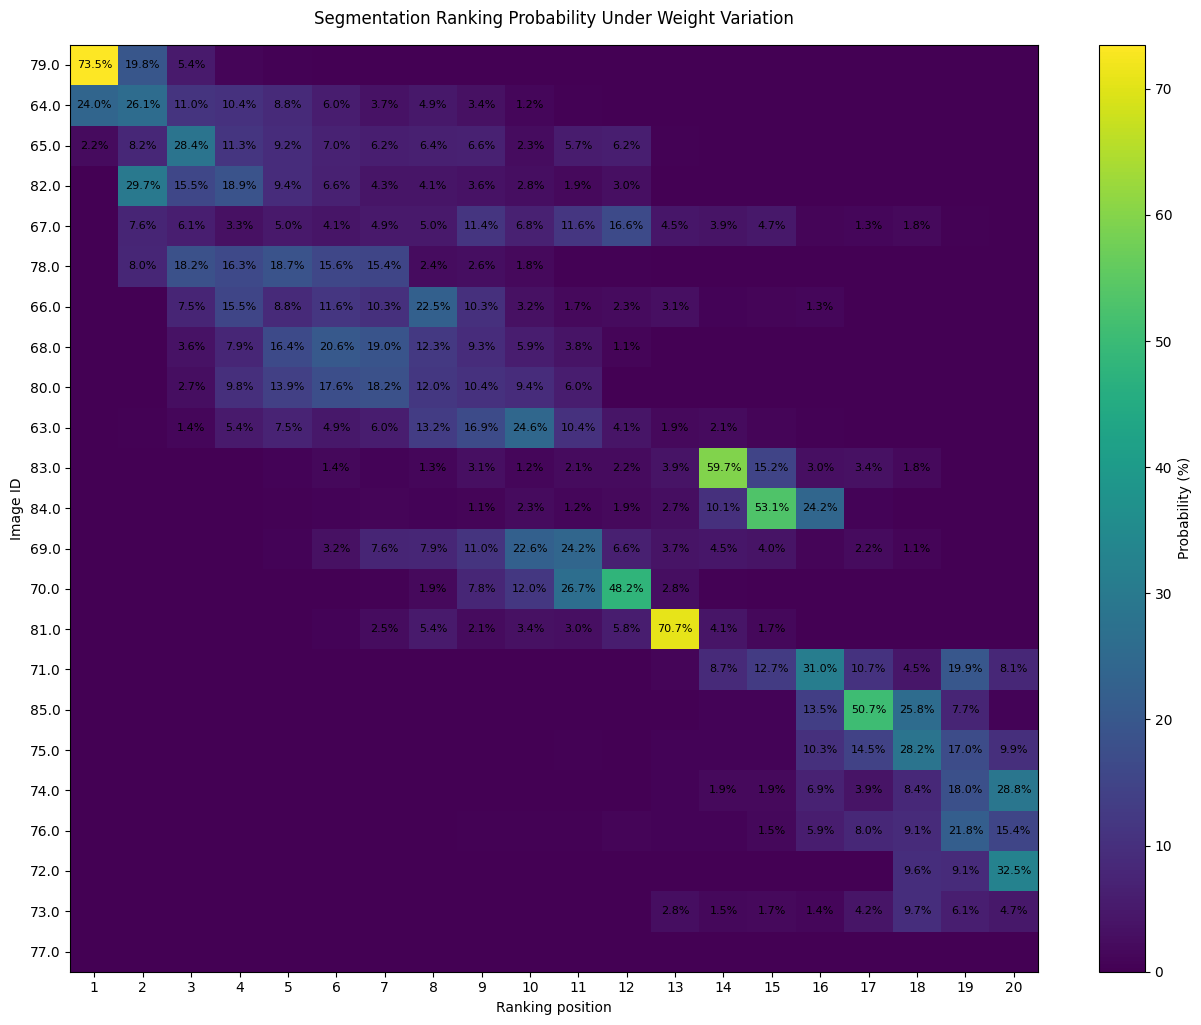

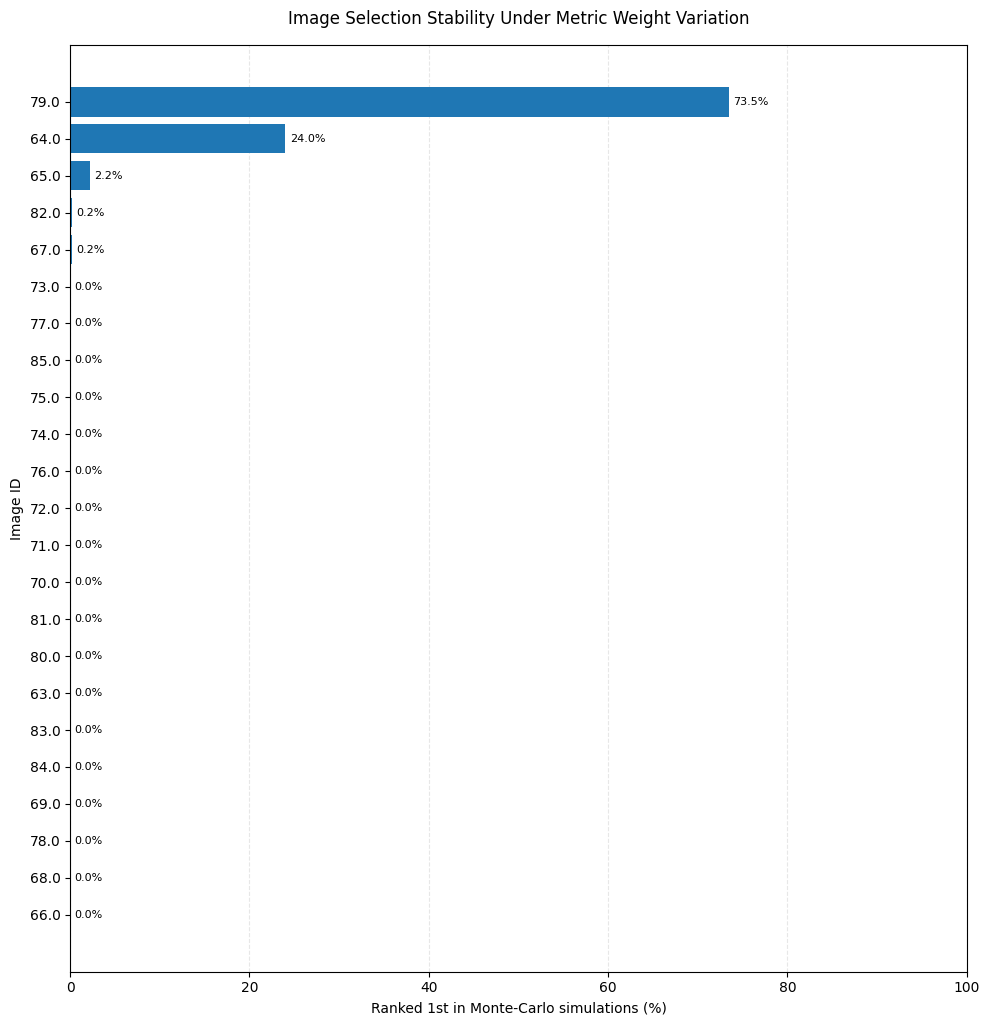

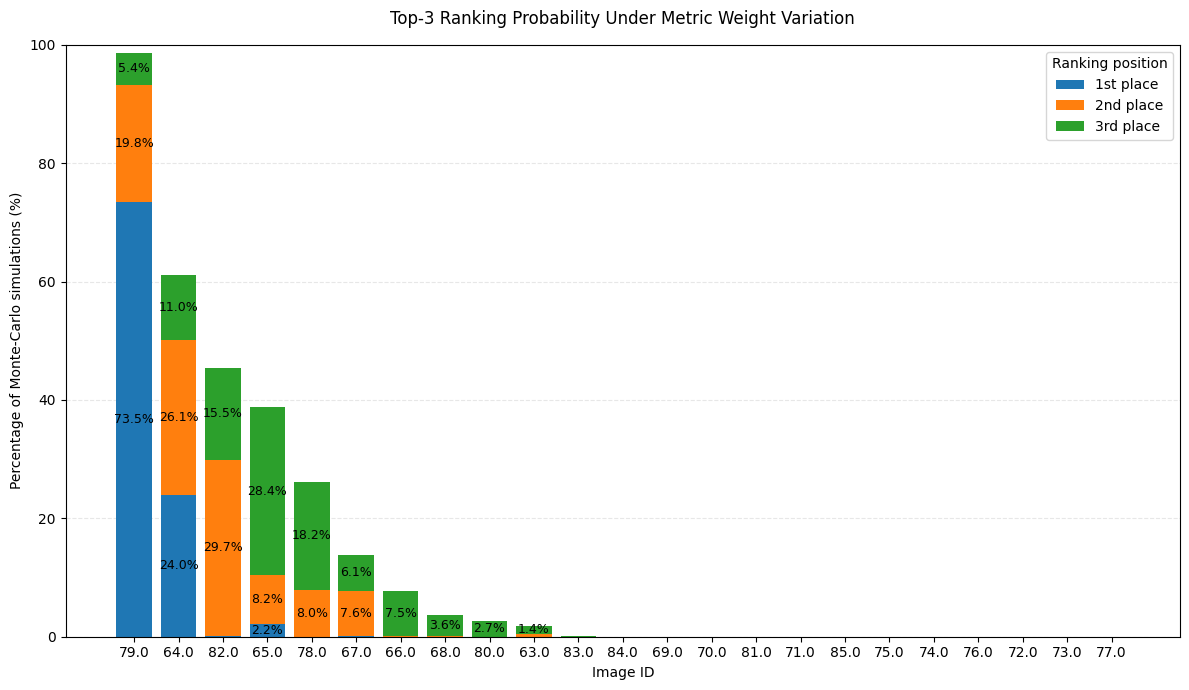


Monte-Carlo Weight Sensitivity Analysis

Input file:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\results\Param_8\segmentation_quality_param_8.csv

Number of images:
23

Number of simulations:
100,000

Random seed:
42

----------------------------------------
Output files
----------------------------------------

Ranking statistics:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\results\Param_8\segmentation_weight_sensitivity\segmentation_quality_param_8_ranking_statistics.csv

Rank probability:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\results\Param_8\segmentation_weight_sensitivity\segmentation_quality_param_8_rank_probability.csv

Random weights:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\results\Param_8\segmentation_weight_sensitivity\segmentation_quality_param_8_random_weights.csv

Rank probability heatmap:
c:\PhD_programs\Code\meizeddin_PhD_code\FIB_SEM_optimization\results\Param_8\segmentation_weight_sensitivity

In [34]:
BASE_DIR = Path.cwd().parents[1]

param = "Param_8"
filename = "segmentation_quality_param_8.csv"

output_dir = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "results"
    / param
    / "segmentation_weight_sensitivity"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

results, weights = segmentation_weight_sensitivity(
    BASE_DIR
    / "FIB_SEM_optimization"
    / "results"
    / param
    / filename,
    output_dir=output_dir
)

In [35]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [36]:
def quality_weight_sensitivity(
    input_file,
    output_dir=None,
    n_simulations=100000,
    random_seed=42,
    max_rank_heatmap=20
):
    """
    Monte-Carlo sensitivity analysis of image-quality metric weights.

    Metrics:
        Entropy
        Sharpness
        Gradient
        RMS_Contrast
        SNR

    Generates:

        1. Rank probability heatmap
        2. 1st-place probability plot
        3. Vertical stacked 1st/2nd/3rd probability plot
        4. Ranking statistics CSV
        5. Rank probability CSV
        6. Random weights CSV

    Parameters
    ----------
    input_file : str or Path
        CSV or Excel file containing image-quality results.

    output_dir : str or Path, optional
        Directory where results are saved.
        If None, results are saved beside the input file.

    n_simulations : int
        Number of random weight combinations.
        Default = 100,000.

    random_seed : int
        Random seed for reproducibility.
        Default = 42.

    max_rank_heatmap : int, optional
        Maximum ranking position displayed in the heatmap.
        The CSV still contains all ranking positions.
        Default = 20.

    Returns
    -------
    sensitivity_results : pandas.DataFrame
        Ranking statistics for every image.

    weight_results : pandas.DataFrame
        Randomly generated metric weights.
    """

    # ============================================================
    # 1. LOAD DATA
    # ============================================================

    input_file = Path(input_file)

    if input_file.suffix.lower() == ".csv":

        quality_results = pd.read_csv(input_file)

    elif input_file.suffix.lower() in [".xlsx", ".xls"]:

        quality_results = pd.read_excel(input_file)

    else:

        raise ValueError(
            "Input file must be CSV or Excel "
            "(.csv, .xlsx, .xls)"
        )

    # ============================================================
    # 2. DEFINE IMAGE QUALITY METRICS
    # ============================================================

    quality_metrics = [
        "Entropy",
        "Sharpness",
        "Gradient",
        "RMS_Contrast",
        "SNR"
    ]

    # Check required columns

    missing_columns = [
        column
        for column in quality_metrics
        if column not in quality_results.columns
    ]

    if missing_columns:

        raise ValueError(
            f"Missing required columns: {missing_columns}"
        )

    # Check image ID

    if "image_id" not in quality_results.columns:

        raise ValueError(
            "The input file must contain an 'image_id' column."
        )

    # ============================================================
    # 3. CHECK MISSING VALUES
    # ============================================================

    if quality_results[
        quality_metrics
    ].isnull().any().any():

        missing_metrics = (
            quality_results[
                quality_metrics
            ]
            .isnull()
            .sum()
        )

        missing_metrics = (
            missing_metrics[
                missing_metrics > 0
            ]
        )

        raise ValueError(
            "Missing values found in image-quality metrics:\n"
            f"{missing_metrics}"
        )

    # ============================================================
    # 4. NORMALISE IMAGE QUALITY METRICS
    # ============================================================

    scaler = MinMaxScaler()

    normalized = scaler.fit_transform(
        quality_results[
            quality_metrics
        ]
    )

    normalized_results = pd.DataFrame(
        normalized,
        columns=quality_metrics,
        index=quality_results.index
    )

    # ------------------------------------------------------------
    # All metrics:
    #
    # HIGHER = BETTER
    #
    # Therefore no inversion is required.
    # ------------------------------------------------------------

    normalized_array = (
        normalized_results[
            quality_metrics
        ].to_numpy()
    )

    # ============================================================
    # 5. GENERATE RANDOM WEIGHTS
    # ============================================================

    rng = np.random.default_rng(
        random_seed
    )

    random_weights = rng.dirichlet(
        alpha=np.ones(
            len(quality_metrics)
        ),
        size=n_simulations
    )

    weight_results = pd.DataFrame(
        random_weights,
        columns=quality_metrics
    )

    weight_results.insert(
        0,
        "simulation",
        np.arange(
            1,
            n_simulations + 1
        )
    )

    # ============================================================
    # 6. CALCULATE SCORES AND RANKS
    # ============================================================

    n_images = len(
        quality_results
    )

    all_ranks = np.zeros(
        (
            n_simulations,
            n_images
        ),
        dtype=np.int16
    )

    for i in range(
        n_simulations
    ):

        # Random metric weights

        weights_i = random_weights[i]

        # Calculate weighted image-quality score

        scores = (
            normalized_array
            @ weights_i
        )

        # Rank images

        ranks = (
            pd.Series(scores)
            .rank(
                ascending=False,
                method="min"
            )
            .to_numpy()
        )

        all_ranks[i] = ranks

    image_ids = (
        quality_results[
            "image_id"
        ].to_numpy()
    )

    # ============================================================
    # 7. CALCULATE RANKING STATISTICS
    # ============================================================

    sensitivity_results = pd.DataFrame({

        "image_id": image_ids,

        "first_place_percent":
            np.mean(
                all_ranks == 1,
                axis=0
            ) * 100,

        "second_place_percent":
            np.mean(
                all_ranks == 2,
                axis=0
            ) * 100,

        "third_place_percent":
            np.mean(
                all_ranks == 3,
                axis=0
            ) * 100,

        "top_3_percent":
            np.mean(
                all_ranks <= 3,
                axis=0
            ) * 100,

        "mean_rank":
            np.mean(
                all_ranks,
                axis=0
            ),

        "median_rank":
            np.median(
                all_ranks,
                axis=0
            ),

        "rank_std":
            np.std(
                all_ranks,
                axis=0
            )
    })

    # ------------------------------------------------------------
    # Sort by first-place probability
    # ------------------------------------------------------------

    sensitivity_results = (
        sensitivity_results
        .sort_values(
            [
                "first_place_percent",
                "top_3_percent",
                "mean_rank"
            ],
            ascending=[
                False,
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    # ============================================================
    # 8. FULL RANK PROBABILITY DISTRIBUTION
    # ============================================================

    rank_probability_matrix = np.zeros(
        (
            n_images,
            n_images
        )
    )

    for rank in range(
        1,
        n_images + 1
    ):

        rank_probability_matrix[
            :,
            rank - 1
        ] = (
            np.mean(
                all_ranks == rank,
                axis=0
            ) * 100
        )

    rank_probability_results = pd.DataFrame(
        rank_probability_matrix,
        columns=[
            f"rank_{rank}_percent"
            for rank in range(
                1,
                n_images + 1
            )
        ]
    )

    rank_probability_results.insert(
        0,
        "image_id",
        image_ids
    )

    # ------------------------------------------------------------
    # Sort using same image order as sensitivity_results
    # ------------------------------------------------------------

    rank_order = (
        sensitivity_results[
            "image_id"
        ].tolist()
    )

    rank_probability_results = (
        rank_probability_results
        .set_index(
            "image_id"
        )
        .loc[
            rank_order
        ]
        .reset_index()
    )

    # ============================================================
    # 9. OUTPUT DIRECTORY
    # ============================================================

    if output_dir is None:

        output_dir = input_file.parent

    output_dir = Path(
        output_dir
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    parameter_name = (
        input_file.stem
    )

    # ============================================================
    # 10. ROUND TO 6 SIGNIFICANT FIGURES
    # ============================================================

    def round_to_sig_figs(
        dataframe,
        sig_figs=6
    ):

        dataframe = dataframe.copy()

        numeric_columns = (
            dataframe
            .select_dtypes(
                include=[np.number]
            )
            .columns
        )

        for column in numeric_columns:

            dataframe[column] = (
                dataframe[column]
                .map(
                    lambda value:
                    (
                        0
                        if value == 0
                        else float(
                            f"{value:.{sig_figs}g}"
                        )
                    )
                )
            )

        return dataframe

    sensitivity_results = (
        round_to_sig_figs(
            sensitivity_results
        )
    )

    rank_probability_results = (
        round_to_sig_figs(
            rank_probability_results
        )
    )

    weight_results = (
        round_to_sig_figs(
            weight_results
        )
    )

    # ============================================================
    # 11. SAVE CSV FILES
    # ============================================================

    statistics_file = (
        output_dir
        / f"{parameter_name}_ranking_statistics.csv"
    )

    sensitivity_results.to_csv(
        statistics_file,
        index=False
    )

    rank_probability_file = (
        output_dir
        / f"{parameter_name}_rank_probability.csv"
    )

    rank_probability_results.to_csv(
        rank_probability_file,
        index=False
    )

    weights_file = (
        output_dir
        / f"{parameter_name}_random_weights.csv"
    )

    weight_results.to_csv(
        weights_file,
        index=False
    )

    # ============================================================
    # 12. RANK PROBABILITY HEATMAP
    # ============================================================

    heatmap_data = (
        rank_probability_results
        .set_index(
            "image_id"
        )
    )

    if max_rank_heatmap is not None:

        max_rank_heatmap = min(
            max_rank_heatmap,
            n_images
        )

        heatmap_data = (
            heatmap_data.iloc[
                :,
                :max_rank_heatmap
            ]
        )

    heatmap_data.columns = [
        column
        .replace(
            "rank_",
            ""
        )
        .replace(
            "_percent",
            ""
        )
        for column in heatmap_data.columns
    ]

    fig_height = max(
        6,
        len(
            heatmap_data
        ) * 0.45
    )

    fig_width = max(
        10,
        len(
            heatmap_data.columns
        ) * 0.65
    )

    fig, ax = plt.subplots(
        figsize=(
            fig_width,
            fig_height
        )
    )

    image = ax.imshow(
        heatmap_data.values,
        aspect="auto",
        interpolation="nearest"
    )

    ax.set_xticks(
        np.arange(
            len(
                heatmap_data.columns
            )
        )
    )

    ax.set_xticklabels(
        heatmap_data.columns
    )

    ax.set_yticks(
        np.arange(
            len(
                heatmap_data.index
            )
        )
    )

    ax.set_yticklabels(
        heatmap_data.index
    )

    ax.set_xlabel(
        "Ranking position"
    )

    ax.set_ylabel(
        "Image ID"
    )

    ax.set_title(
        "Image Quality Ranking Probability Under Weight Variation",
        pad=15
    )

    # ------------------------------------------------------------
    # Percentage annotations
    # ------------------------------------------------------------

    for i in range(
        heatmap_data.shape[0]
    ):

        for j in range(
            heatmap_data.shape[1]
        ):

            value = (
                heatmap_data.iloc[
                    i,
                    j
                ]
            )

            if value >= 1:

                ax.text(
                    j,
                    i,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8
                )

    # ------------------------------------------------------------
    # Colour bar
    # ------------------------------------------------------------

    cbar = fig.colorbar(
        image,
        ax=ax
    )

    cbar.set_label(
        "Probability (%)"
    )

    plt.tight_layout()

    heatmap_file = (
        output_dir
        / f"{parameter_name}_rank_probability_heatmap.png"
    )

    plt.savefig(
        heatmap_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # ============================================================
    # 13. 1ST-PLACE PROBABILITY PLOT
    # ============================================================

    plot_results = (
        sensitivity_results
        .sort_values(
            "first_place_percent",
            ascending=True
        )
    )

    fig_height = max(
        6,
        len(
            plot_results
        ) * 0.45
    )

    fig, ax = plt.subplots(
        figsize=(
            10,
            fig_height
        )
    )

    bars = ax.barh(
        plot_results[
            "image_id"
        ].astype(str),
        plot_results[
            "first_place_percent"
        ]
    )

    ax.set_xlabel(
        "Ranked 1st in Monte-Carlo simulations (%)"
    )

    ax.set_ylabel(
        "Image ID"
    )

    ax.set_title(
        "Image Quality Selection Stability Under Metric Weight Variation",
        pad=15
    )

    ax.set_xlim(
        0,
        max(
            100,
            plot_results[
                "first_place_percent"
            ].max() * 1.10
        )
    )

    # ------------------------------------------------------------
    # Percentage labels
    # ------------------------------------------------------------

    for bar, value in zip(
        bars,
        plot_results[
            "first_place_percent"
        ]
    ):

        ax.text(
            bar.get_width() + 0.5,
            bar.get_y()
            + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            fontsize=8
        )

    ax.set_axisbelow(True)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    first_place_file = (
        output_dir
        / f"{parameter_name}_first_place_probability.png"
    )

    plt.savefig(
        first_place_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # ============================================================
    # 14. VERTICAL STACKED 1ST / 2ND / 3RD PROBABILITY
    # ============================================================

    stacked_results = (
        sensitivity_results
        .sort_values(
            "top_3_percent",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    x = np.arange(
        len(
            stacked_results
        )
    )

    first = (
        stacked_results[
            "first_place_percent"
        ].to_numpy()
    )

    second = (
        stacked_results[
            "second_place_percent"
        ].to_numpy()
    )

    third = (
        stacked_results[
            "third_place_percent"
        ].to_numpy()
    )

    # ------------------------------------------------------------
    # Figure
    # ------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            12,
            7
        )
    )

    # ------------------------------------------------------------
    # Stacked bars
    # ------------------------------------------------------------

    ax.bar(
        x,
        first,
        label="1st place"
    )

    ax.bar(
        x,
        second,
        bottom=first,
        label="2nd place"
    )

    ax.bar(
        x,
        third,
        bottom=(
            first
            + second
        ),
        label="3rd place"
    )

    # ============================================================
    # 15. ADD PERCENTAGES INSIDE STACKED BARS
    # ============================================================

    for i in range(
        len(x)
    ):

        # 1st place

        if first[i] >= 1:

            ax.text(
                x[i],
                first[i] / 2,
                f"{first[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        # 2nd place

        if second[i] >= 1:

            ax.text(
                x[i],
                first[i]
                + second[i] / 2,
                f"{second[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        # 3rd place

        if third[i] >= 1:

            ax.text(
                x[i],
                first[i]
                + second[i]
                + third[i] / 2,
                f"{third[i]:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    # ============================================================
    # 16. FORMAT STACKED PLOT
    # ============================================================

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        stacked_results[
            "image_id"
        ].astype(str)
    )

    ax.set_xlabel(
        "Image ID"
    )

    ax.set_ylabel(
        "Percentage of Monte-Carlo simulations (%)"
    )

    ax.set_title(
        "Top-3 Image Quality Ranking Probability Under Metric Weight Variation",
        pad=15
    )

    ax.set_ylim(
        0,
        100
    )

    ax.set_axisbelow(True)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.legend(
        title="Ranking position"
    )

    plt.tight_layout()

    stacked_file = (
        output_dir
        / f"{parameter_name}_top_3_probability_stacked.png"
    )

    plt.savefig(
        stacked_file,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    # ============================================================
    # 17. PRINT SUMMARY
    # ============================================================

    print("\n========================================")
    print("Monte-Carlo Image Quality Weight Sensitivity Analysis")
    print("========================================")

    print("\nInput file:")
    print(input_file)

    print("\nNumber of images:")
    print(n_images)

    print("\nNumber of simulations:")
    print(
        f"{n_simulations:,}"
    )

    print("\nRandom seed:")
    print(
        random_seed
    )

    print("\nMetrics:")
    for metric in quality_metrics:
        print(
            f"  - {metric}"
        )

    print("\n----------------------------------------")
    print("Output files")
    print("----------------------------------------")

    print("\nRanking statistics:")
    print(
        statistics_file
    )

    print("\nRank probability:")
    print(
        rank_probability_file
    )

    print("\nRandom weights:")
    print(
        weights_file
    )

    print("\nRank probability heatmap:")
    print(
        heatmap_file
    )

    print("\n1st-place probability plot:")
    print(
        first_place_file
    )

    print("\nTop-3 stacked probability plot:")
    print(
        stacked_file
    )

    # ============================================================
    # 18. PRINT TOP 10
    # ============================================================

    print("\n----------------------------------------")
    print("Top 10 images")
    print("----------------------------------------")

    print(
        sensitivity_results[
            [
                "image_id",
                "first_place_percent",
                "second_place_percent",
                "third_place_percent",
                "top_3_percent",
                "mean_rank",
                "median_rank",
                "rank_std"
            ]
        ].head(10)
    )

    # ============================================================
    # 19. RETURN
    # ============================================================

    return (
        sensitivity_results,
        weight_results
    )

In [ ]:
BASE_DIR = Path.cwd().parents[1]

param = "Param_1"
filename = "merged_quality_results_param_1.csv"

output_dir = (
    BASE_DIR
    / "FIB_SEM_optimization"
    / "results"
    / param
    / "segmentation_weight_sensitivity"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

results, weights = segmentation_weight_sensitivity(
    BASE_DIR
    / "FIB_SEM_optimization"
    / "results"
    / param
    / filename,
    output_dir=output_dir
)